In [ ]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

from src.data_loader import get_train_test
from src.preprocess import apply_cleaning

X_train, y_train, X_test, y_test = get_train_test(
    "../data/raw/train.csv",
    "../data/raw/test.csv"
)

X_train_clean = apply_cleaning(X_train)
X_test_clean = apply_cleaning(X_test)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=2000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ))
])

pipeline.fit(X_train_clean, y_train)

y_pred = pipeline.predict(X_test_clean)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("\nClassification report:\n", classification_report(y_test, y_pred))


c:\Users\aarti\OneDrive\Desktop\Github\Intelligent-News-Classifier\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.8825
Macro F1: 0.8822773892698674

Classification report:
               precision    recall  f1-score   support

           1       0.90      0.89      0.89      1900
           2       0.93      0.95      0.94      1900
           3       0.85      0.84      0.84      1900
           4       0.85      0.85      0.85      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.88      0.88      7600
weighted avg       0.88      0.88      0.88      7600



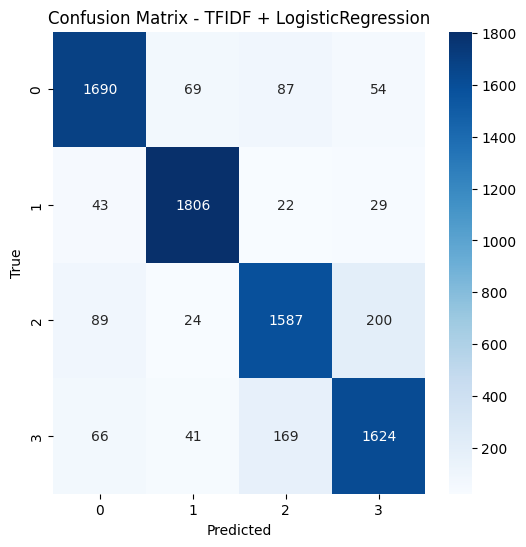

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - TFIDF + LogisticRegression")
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/confusion_matrix_baseline.png", bbox_inches="tight")
plt.show()


In [ ]:
os.makedirs("../models", exist_ok=True)
joblib.dump(pipeline, "../models/tfidf_logreg.pkl")
print("Saved model to models/tfidf_logreg.pkl")


Saved model to models/tfidf_logreg.pkl
